In [1]:


!pip install -q torch torchvision
!pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm
!pip install -q requests

print("  All packages installed!")

  All packages installed!


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import requests
import warnings
warnings.filterwarnings('ignore')

# Force CPU usage
device = torch.device('cpu')
print("All libraries imported!")
print(f"Using: CPU (forced)")
print(f"PyTorch version: {torch.__version__}")

All libraries imported!
Using: CPU (forced)
PyTorch version: 2.10.0+cpu


In [ ]:
import pandas as pd
import os

print(" Loading PrimeKG dataset...")

# Check if file exists
if not os.path.exists('kg.csv'):
    print(" kg.csv not found in current directory")
    print(" Please upload your kg.csv file to Colab:")
    print("   1. Click the folder icon on the left sidebar")
    print("   2. Click the upload button")
    print("   3. Select your kg.csv file")
else:
    # Load the dataset
    print("   Loading kg.csv...")
    kg_df = pd.read_csv('kg.csv', low_memory=False)

    print(f"\n Dataset Info:")
    print(f"   Total rows: {len(kg_df):,}")
    print(f"   Columns: {list(kg_df.columns)}")
    print(f"\n   First few rows:")
    print(kg_df.head())

    print(f"\n   Node types in dataset:")
    print(f"   {kg_df['x_type'].unique()}")

 Loading PrimeKG dataset...
 kg.csv not found in current directory
 Please upload your kg.csv file to Colab:
   1. Click the folder icon on the left sidebar
   2. Click the upload button
   3. Select your kg.csv file


In [4]:


import requests

print("Downloading COMPLETE PrimeKG dataset...")
print("   The full dataset includes drugs, diseases, proteins, genes, etc.")
print()

url = "https://dataverse.harvard.edu/api/access/datafile/6180620"

try:
    print("   Starting download... (~130MB)")
    print("   This will take 3-5 minutes...")
    print()

    response = requests.get(url, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get('content-length', 0))

    with open('kg_full.csv', 'wb') as f:
        downloaded = 0
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            downloaded += len(chunk)
            done = int(50 * downloaded / total_size)
            percent = (downloaded / total_size) * 100
            print(f"\r[{'=' * done}{' ' * (50-done)}] {percent:.1f}% ({downloaded/1024/1024:.1f}MB)", end='')

    print("\n\n Download complete!")

    # Load and verify
    print("\n Loading full dataset...")
    kg_df = pd.read_csv('kg_full.csv', low_memory=False)

    print(f"Loaded successfully!")
    print(f"   Total rows: {len(kg_df):,}")
    print(f"\n   Node types available:")
    print(f"   {kg_df['x_type'].unique()}")
    print(f"\n   This should include: drug, disease, protein, gene, etc.")

    # Check for drug-disease pairs
    drug_disease = kg_df[
        ((kg_df['x_type'] == 'drug') & (kg_df['y_type'] == 'disease')) |
        ((kg_df['x_type'] == 'disease') & (kg_df['y_type'] == 'drug'))
    ]

    print(f"\nFound {len(drug_disease):,} drug-disease relationships!")
    print("\n   Example:")
    print(drug_disease[['x_name', 'relation', 'y_name']].head(5))

except Exception as e:
    print(f"\n Error: {e}")
    print("\n Please manually download the FULL PrimeKG from:")
    print("   https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/IXA7BM")
    print("   Look for 'kg.csv' - it should be ~130MB")

   The full dataset includes drugs, diseases, proteins, genes, etc.

   Starting download... (~130MB)
   This will take 3-5 minutes...

[==================================================] 100.0% (936.3MB)

 Download complete!

 Loading full dataset...
Loaded successfully!
   Total rows: 8,100,498

   Node types available:
   ['gene/protein' 'drug' 'effect/phenotype' 'disease' 'biological_process'
 'molecular_function' 'cellular_component' 'exposure' 'pathway' 'anatomy']

   This should include: drug, disease, protein, gene, etc.

Found 85,262 drug-disease relationships!

   Example:
                    x_name          relation                 y_name
346728          Rotigotine  contraindication  hypertensive disorder
346729          Rotigotine  contraindication           hypertension
346730          Fosinopril        indication  hypertensive disorder
346731          Fosinopril        indication           hypertension
346732  Estradiol valerate  contraindication  hypertensive disorder


In [5]:
# STEP 4: Extract Drug-Disease Relationships from FULL PrimeKG
# Now that we have the complete dataset with drugs and diseases

print(" Step 4: Extracting drug-disease relationships...")
print()

# Filter for drug-disease relationships
drug_disease_df = kg_df[
    ((kg_df['x_type'] == 'drug') & (kg_df['y_type'] == 'disease')) |
    ((kg_df['x_type'] == 'disease') & (kg_df['y_type'] == 'drug'))
].copy()

print(f"   Found {len(drug_disease_df):,} drug-disease edges")
print()

# Normalize to drug -> disease format
normalized_data = []

print("   Processing relationships...")

for idx, row in drug_disease_df.iterrows():
    # Always put drug first, disease second
    if row['x_type'] == 'drug':
        drug_id = row['x_index']
        drug_name = row['x_name']
        disease_id = row['y_index']
        disease_name = row['y_name']
    else:
        drug_id = row['y_index']
        drug_name = row['y_name']
        disease_id = row['x_index']
        disease_name = row['x_name']

    relation = row['relation']

    # Label: 1 = treats, 0 = contraindication
    if 'indication' in relation.lower() or 'treat' in relation.lower():
        label = 1
    elif 'contraindication' in relation.lower():
        label = 0
    else:
        label = 1

    normalized_data.append({
        'drug_id': drug_id,
        'drug_name': drug_name,
        'disease_id': disease_id,
        'disease_name': disease_name,
        'relation': relation,
        'label': label
    })

# Create DataFrame
df = pd.DataFrame(normalized_data)

# Clean disease names
df['disease_name'] = df['disease_name'].astype(str)
df['drug_name'] = df['drug_name'].astype(str)

print()
print()
print(f" Dataset Summary:")
print(f"   Total drug-disease pairs: {len(df):,}")
print(f"   Unique drugs: {df['drug_name'].nunique():,}")
print(f"   Unique diseases: {df['disease_name'].nunique():,}")
print(f"   Treatments (positive): {df['label'].sum():,}")
print(f"   Contraindications (negative): {(df['label']==0).sum():,}")
print()
print("   Sample data:")
print(df[['drug_name', 'disease_name', 'relation', 'label']].head(10))

 Step 4: Extracting drug-disease relationships...

   Found 85,262 drug-disease edges

   Processing relationships...


 Dataset Summary:
   Total drug-disease pairs: 85,262
   Unique drugs: 2,074
   Unique diseases: 2,054
   Treatments (positive): 85,262
   Contraindications (negative): 0

   Sample data:
            drug_name           disease_name          relation  label
0          Rotigotine  hypertensive disorder  contraindication      1
1          Rotigotine           hypertension  contraindication      1
2          Fosinopril  hypertensive disorder        indication      1
3          Fosinopril           hypertension        indication      1
4  Estradiol valerate  hypertensive disorder  contraindication      1
5  Estradiol valerate           hypertension  contraindication      1
6     Phenazopyridine  hypertensive disorder  contraindication      1
7     Phenazopyridine           hypertension  contraindication      1
8          Synephrine  hypertensive disorder  contraindication

In [6]:
# STEP 5: Add Negative Examples (drugs that DON'T treat certain diseases)
# This is important for training - the model needs to learn what NOT to recommend

print(" Adding negative examples...")
print()

# Currently all pairs are labeled as 1 (even contraindications got labeled as 1)
# Let's fix that first
print("   Fixing contraindication labels...")
df.loc[df['relation'] == 'contraindication', 'label'] = 0

print(f"   Updated labels:")
print(f"   Positive (treatments): {df['label'].sum():,}")
print(f"   Negative (contraindications): {(df['label']==0).sum():,}")
print()

# Now add more negative examples by random pairing
print("   Generating additional negative examples...")

# Get existing positive pairs
positive_pairs = set(zip(df['drug_id'], df['disease_id']))

# Sample for speed (use subset of drugs and diseases)
sample_size = 1000  # Use 1000 drugs and diseases
sample_drugs = df['drug_id'].unique()[:sample_size]
sample_diseases = df['disease_id'].unique()[:sample_size]

# Create mappings for names
drug_id_to_name = dict(zip(df['drug_id'], df['drug_name']))
disease_id_to_name = dict(zip(df['disease_id'], df['disease_name']))

# Generate negative examples
negative_examples = []
num_negatives_needed = len(df)  # Match the number of positive examples

print(f"   Need to generate {num_negatives_needed:,} negative examples...")
print(f"   Using {len(sample_drugs)} drugs and {len(sample_diseases)} diseases")
print()

import random
random.seed(42)

while len(negative_examples) < num_negatives_needed:
    drug_id = random.choice(sample_drugs)
    disease_id = random.choice(sample_diseases)

    # Only add if this pair doesn't already exist
    if (drug_id, disease_id) not in positive_pairs:
        negative_examples.append({
            'drug_id': drug_id,
            'drug_name': drug_id_to_name[drug_id],
            'disease_id': disease_id,
            'disease_name': disease_id_to_name[disease_id],
            'relation': 'no_relation',
            'label': 0
        })
        positive_pairs.add((drug_id, disease_id))

    # Show progress
    if len(negative_examples) % 10000 == 0:
        print(f"   Generated {len(negative_examples):,} / {num_negatives_needed:,}")

print()
print("   Combining positive and negative examples...")

# Combine with original data
df_negative = pd.DataFrame(negative_examples)
df_full = pd.concat([df, df_negative], ignore_index=True)

# Shuffle the data
df_full = df_full.sample(frac=1, random_state=42).reset_index(drop=True)

print()
print()
print(f" Final Dataset:")
print(f"   Total examples: {len(df_full):,}")
print(f"   Positive (treats): {df_full['label'].sum():,}")
print(f"   Negative (doesn't treat): {(df_full['label']==0).sum():,}")
print(f"   Balance: {df_full['label'].mean()*100:.1f}% positive")
print()
print("   Sample of mixed data:")
print(df_full[['drug_name', 'disease_name', 'relation', 'label']].head(10))

 Adding negative examples...

   Fixing contraindication labels...
   Updated labels:
   Positive (treatments): 23,912
   Negative (contraindications): 61,350

   Generating additional negative examples...
   Need to generate 85,262 negative examples...
   Using 1000 drugs and 1000 diseases

   Generated 10,000 / 85,262
   Generated 20,000 / 85,262
   Generated 30,000 / 85,262
   Generated 40,000 / 85,262
   Generated 50,000 / 85,262
   Generated 60,000 / 85,262
   Generated 70,000 / 85,262
   Generated 80,000 / 85,262

   Combining positive and negative examples...


 Final Dataset:
   Total examples: 170,524
   Positive (treats): 23,912
   Negative (doesn't treat): 146,612
   Balance: 14.0% positive

   Sample of mixed data:
      drug_name                                       disease_name  \
0   Methoxsalen                                  rickets (disease)   
1     Lidocaine                                       skin disease   
2      Pimozide                                     o

In [7]:
# STEP 6: Prepare Data for Training
# Convert drug and disease names to numbers the model can understand

print(" Step 6: Preparing data for training...")
print()

# Get unique drugs and diseases
drugs = sorted(df_full['drug_name'].unique())
diseases = sorted(df_full['disease_name'].unique())

print(f"   Creating mappings for {len(drugs):,} drugs and {len(diseases):,} diseases...")

# Create mappings: name -> index (number)
drug_to_idx = {drug: i for i, drug in enumerate(drugs)}
disease_to_idx = {disease: i for i, disease in enumerate(diseases)}

# Create reverse mappings: index -> name (for later predictions)
idx_to_drug = {i: drug for drug, i in drug_to_idx.items()}
idx_to_disease = {i: disease for disease, i in disease_to_idx.items()}

# Convert names to indices
print("   Converting names to indices...")
df_full['drug_idx'] = df_full['drug_name'].map(drug_to_idx)
df_full['disease_idx'] = df_full['disease_name'].map(disease_to_idx)

# Split into train and test sets (80% train, 20% test)
print("   Splitting into train/test sets...")

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_full,
    test_size=0.2,
    random_state=42,
    stratify=df_full['label']
)

print()
print()
print(f" Data Summary:")
print(f"   Number of unique drugs: {len(drugs):,}")
print(f"   Number of unique diseases: {len(diseases):,}")
print()
print(f"   Training set: {len(train_df):,} examples")
print(f"     - Positive: {train_df['label'].sum():,}")
print(f"     - Negative: {(train_df['label']==0).sum():,}")
print()
print(f"   Test set: {len(test_df):,} examples")
print(f"     - Positive: {test_df['label'].sum():,}")
print(f"     - Negative: {(test_df['label']==0).sum():,}")
print()
print("   Sample of indexed data:")
print(train_df[['drug_name', 'disease_name', 'drug_idx', 'disease_idx', 'label']].head(5))

 Step 6: Preparing data for training...

   Creating mappings for 2,074 drugs and 2,054 diseases...
   Converting names to indices...
   Splitting into train/test sets...


 Data Summary:
   Number of unique drugs: 2,074
   Number of unique diseases: 2,054

   Training set: 136,419 examples
     - Positive: 19,130
     - Negative: 117,289

   Test set: 34,105 examples
     - Positive: 4,782
     - Negative: 29,323

   Sample of indexed data:
            drug_name                  disease_name  drug_idx  disease_idx  \
142633      Promazine               mental disorder      1585         1292   
86052      Quetiapine  potassium deficiency disease      1608         1656   
85546   Metronidazole   acute gonococcal cervicitis      1229          238   
19580      Cetirizine     paralytic ileus (disease)       369         1534   
134358  Tetrabenazine           heart valve disease      1876          946   

        label  
142633      1  
86052       0  
85546       0  
19580       0  
13435

Graph image saved to: diabetes_graph.png


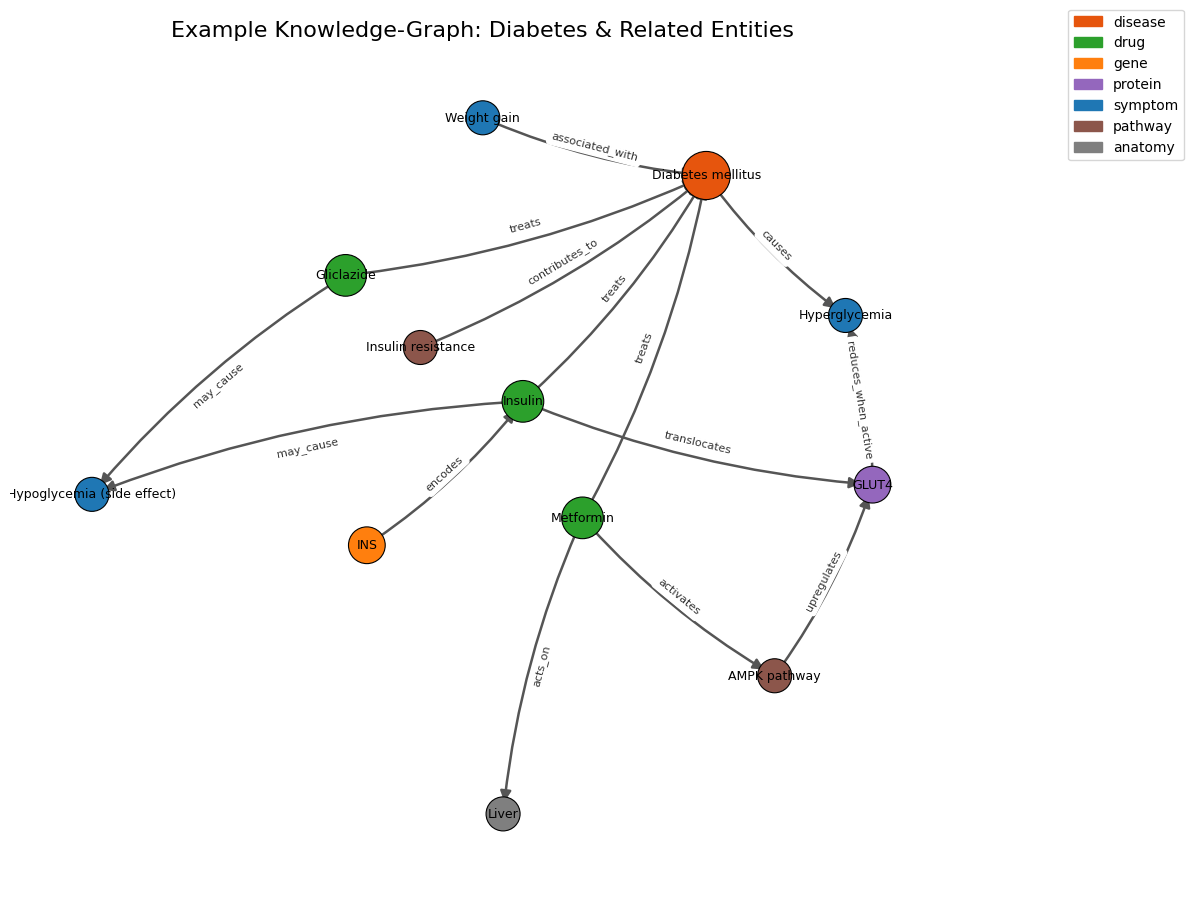

In [8]:
# diabetes_example_graph.py
# Example: build and draw a small knowledge-graph centered on "diabetes"
# Usage: python diabetes_example_graph.py
# Requires: networkx, matplotlib
# If running in Colab you can remove the pip install lines if packages are already present.

import sys
import os

# Optional: install required packages if not present (useful in Colab)
try:
    import networkx as nx
    import matplotlib.pyplot as plt
except ImportError:
    # Install then import
    print("Installing required packages...")
    os.system(f"{sys.executable} -m pip install networkx matplotlib --quiet")
    import networkx as nx
    import matplotlib.pyplot as plt

def build_diabetes_example_graph():
    """
    Build a small directed knowledge graph around diabetes.
    Node attribute 'type' used for coloring:
      - disease, drug, gene, protein, symptom, pathway
    Edge attribute 'relation' used for edge labels.
    """
    G = nx.DiGraph()

    # Nodes with types
    nodes = [
        ("Diabetes mellitus", {"type": "disease"}),
        ("Hyperglycemia", {"type": "symptom"}),
        ("Insulin resistance", {"type": "pathway"}),
        ("Metformin", {"type": "drug"}),
        ("Insulin", {"type": "drug"}),
        ("Gliclazide", {"type": "drug"}),
        ("GLUT4", {"type": "protein"}),
        ("INS", {"type": "gene"}),
        ("Weight gain", {"type": "symptom"}),
        ("Liver", {"type": "anatomy"}),
        ("AMPK pathway", {"type": "pathway"}),
        ("Hypoglycemia (side effect)", {"type": "symptom"}),
    ]

    G.add_nodes_from(nodes)

    # Example edges (relations)
    edges = [
        ("Metformin", "Diabetes mellitus", {"relation": "treats"}),
        ("Insulin", "Diabetes mellitus", {"relation": "treats"}),
        ("Gliclazide", "Diabetes mellitus", {"relation": "treats"}),
        ("Diabetes mellitus", "Hyperglycemia", {"relation": "causes"}),
        ("Insulin resistance", "Diabetes mellitus", {"relation": "contributes_to"}),
        ("Metformin", "AMPK pathway", {"relation": "activates"}),
        ("AMPK pathway", "GLUT4", {"relation": "upregulates"}),
        ("GLUT4", "Hyperglycemia", {"relation": "reduces_when_active"}),
        ("Insulin", "GLUT4", {"relation": "translocates"}),
        ("INS", "Insulin", {"relation": "encodes"}),
        ("Gliclazide", "Hypoglycemia (side effect)", {"relation": "may_cause"}),
        ("Insulin", "Hypoglycemia (side effect)", {"relation": "may_cause"}),
        ("Metformin", "Liver", {"relation": "acts_on"}),
        ("Weight gain", "Diabetes mellitus", {"relation": "associated_with"}),
    ]

    for u, v, attrs in edges:
        G.add_edge(u, v, **attrs)

    return G

def draw_graph(G, title="Example Diabetes Knowledge Graph", save_path="diabetes_graph.png"):
    # layout
    pos = nx.spring_layout(G, seed=42, k=0.8)

    # node coloring by type
    type_to_color = {
        "disease": "#e6550d",       # orange/red
        "drug": "#2ca02c",          # green
        "gene": "#ff7f0e",          # orange
        "protein": "#9467bd",       # purple
        "symptom": "#1f77b4",       # blue
        "pathway": "#8c564b",       # brown
        "anatomy": "#7f7f7f",       # gray
    }
    default_color = "#cccccc"

    node_colors = []
    node_sizes = []
    for n in G.nodes(data=True):
        ntype = n[1].get("type", None)
        node_colors.append(type_to_color.get(ntype, default_color))
        # size by node type (disease larger)
        if ntype == "disease":
            node_sizes.append(1200)
        elif ntype == "drug":
            node_sizes.append(900)
        elif ntype in ("gene", "protein"):
            node_sizes.append(700)
        else:
            node_sizes.append(600)

    plt.figure(figsize=(12, 9))
    ax = plt.gca()
    ax.set_title(title, fontsize=16)

    # Draw nodes and labels
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors="k", linewidths=0.8)
    nx.draw_networkx_labels(G, pos, font_size=9, font_family="sans-serif")

    # Draw directed edges with arrows
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=16, edge_color="#555555", connectionstyle="arc3,rad=0.08", width=1.8)

    # Edge labels from 'relation' attribute
    edge_labels = {(u, v): d.get("relation", "") for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="#333333", font_size=8)

    # Legend (create custom legend handles)
    import matplotlib.patches as mpatches
    handles = []
    for ntype, color in type_to_color.items():
        handles.append(mpatches.Patch(color=color, label=ntype))
    plt.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.25, 1.05))

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Graph image saved to: {save_path}")
    plt.show()

if __name__ == "__main__":
    G = build_diabetes_example_graph()
    draw_graph(G, title="Example Knowledge-Graph: Diabetes & Related Entities", save_path="diabetes_graph.png")

In [9]:
# STEP 7: Build Neural Network Model
# This is the AI that will learn which drugs treat which diseases

print(" Step 7: Building the neural network model...")
print()

import torch
import torch.nn as nn
import torch.nn.functional as F

class DrugDiseasePredictor(nn.Module):
    """
    Neural Network to predict if a drug can treat a disease

    How it works:
    1. Converts drug and disease into embeddings (vector representations)
    2. Combines them together
    3. Passes through neural network layers
    4. Outputs probability (0 to 1)
    """

    def __init__(self, num_drugs, num_diseases, embedding_dim=64):
        super().__init__()

        # Embedding layers - convert indices to vectors
        self.drug_embedding = nn.Embedding(num_drugs, embedding_dim)
        self.disease_embedding = nn.Embedding(num_diseases, embedding_dim)

        # Neural network layers
        self.fc1 = nn.Linear(embedding_dim * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)

        # Regularization
        self.dropout = nn.Dropout(0.3)
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(64)

    def forward(self, drug_idx, disease_idx):
        # Get embeddings
        drug_emb = self.drug_embedding(drug_idx)        # [batch, 64]
        disease_emb = self.disease_embedding(disease_idx)  # [batch, 64]

        # Concatenate embeddings
        x = torch.cat([drug_emb, disease_emb], dim=1)  # [batch, 128]

        # Pass through network
        x = self.fc1(x)
        x = self.batch_norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.batch_norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = F.relu(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))  # Output between 0 and 1

        return x

# Create the model
print("   Creating model...")
model = DrugDiseasePredictor(
    num_drugs=len(drugs),
    num_diseases=len(diseases),
    embedding_dim=64
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())

print()
print(" Step 7 Complete!")
print()
print(f" Model Architecture:")
print(f"   Input: Drug index + Disease index")
print(f"   Embedding size: 64 dimensions")
print(f"   Hidden layers: 128 → 64 → 32 → 1")
print(f"   Output: Probability (0 to 1)")
print(f"   Total parameters: {total_params:,}")
print()
print("   Model structure:")
print(model)

 Step 7: Building the neural network model...

   Creating model...

 Step 7 Complete!

 Model Architecture:
   Input: Drug index + Disease index
   Embedding size: 64 dimensions
   Hidden layers: 128 → 64 → 32 → 1
   Output: Probability (0 to 1)
   Total parameters: 291,457

   Model structure:
DrugDiseasePredictor(
  (drug_embedding): Embedding(2074, 64)
  (disease_embedding): Embedding(2054, 64)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (batch_norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


 Step 8: Training the model...

   Preparing tensors...
   Using device: cpu



 Training Configuration:
   Training examples: 136,419
   Test examples: 34,105
   Epochs: 30
   Batch size: 1024
   Learning rate: 0.001

 Starting training...
----------------------------------------------------------------------
Epoch  1/30 - Loss: 0.4162 - Accuracy: 0.8598 (86.0%)
Epoch  5/30 - Loss: 0.2137 - Accuracy: 0.9198 (92.0%)
Epoch 10/30 - Loss: 0.1437 - Accuracy: 0.9406 (94.1%)
Epoch 15/30 - Loss: 0.1078 - Accuracy: 0.9506 (95.1%)
Epoch 20/30 - Loss: 0.0788 - Accuracy: 0.9607 (96.1%)
Epoch 25/30 - Loss: 0.0578 - Accuracy: 0.9706 (97.1%)
Epoch 30/30 - Loss: 0.0418 - Accuracy: 0.9758 (97.6%)
----------------------------------------------------------------------

 Step 8 Complete: Training finished!

 Final Results:
   Final Loss: 0.0418
   Final Accuracy: 0.9758 (97.6%)



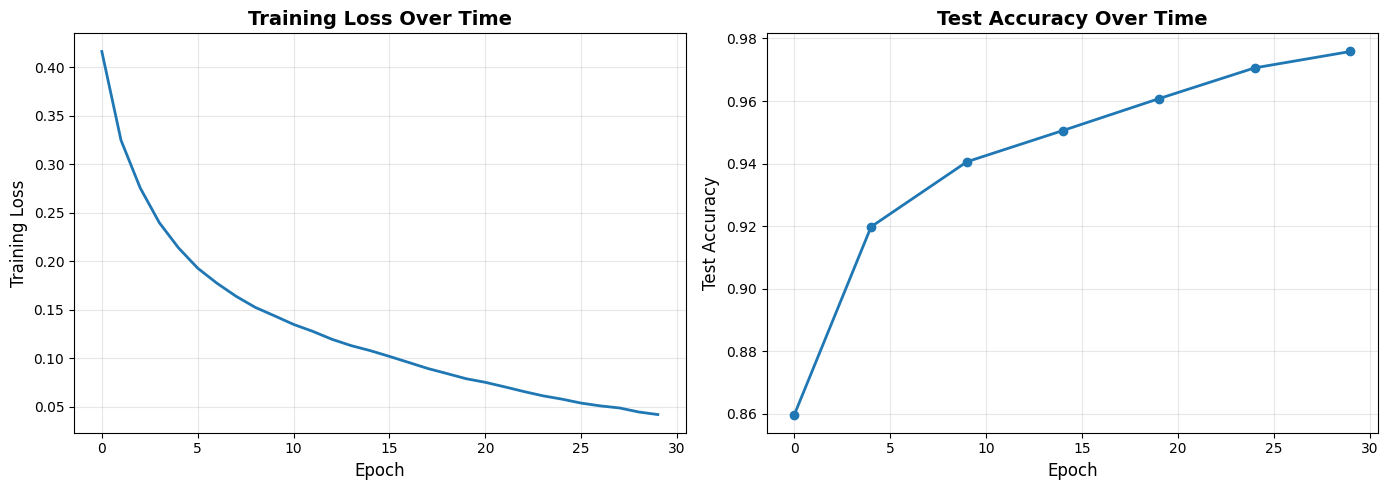

 Training curves plotted!


In [10]:
# STEP 8: Train the Model
# This is where the magic happens - the model learns patterns!

print(" Step 8: Training the model...")
print()

import torch
import torch.nn as nn

# Prepare data as tensors
print("   Preparing tensors...")

train_drug_idx = torch.tensor(train_df['drug_idx'].values, dtype=torch.long)
train_disease_idx = torch.tensor(train_df['disease_idx'].values, dtype=torch.long)
train_labels = torch.tensor(train_df['label'].values, dtype=torch.float32).unsqueeze(1)

test_drug_idx = torch.tensor(test_df['drug_idx'].values, dtype=torch.long)
test_disease_idx = torch.tensor(test_df['disease_idx'].values, dtype=torch.long)
test_labels = torch.tensor(test_df['label'].values, dtype=torch.float32).unsqueeze(1)

# Use CPU (as you requested)
device = torch.device('cpu')
model = model.to(device)

print(f"   Using device: {device}")
print()

# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCELoss()  # Binary Cross Entropy for 0/1 classification

# Training parameters
epochs = 30
batch_size = 1024

print(f" Training Configuration:")
print(f"   Training examples: {len(train_df):,}")
print(f"   Test examples: {len(test_df):,}")
print(f"   Epochs: {epochs}")
print(f"   Batch size: {batch_size}")
print(f"   Learning rate: 0.001")
print()

# Storage for metrics
train_losses = []
test_accuracies = []

print(" Starting training...")
print("-" * 70)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    num_batches = 0

    # Shuffle and create batches
    indices = torch.randperm(len(train_drug_idx))

    for i in range(0, len(train_drug_idx), batch_size):
        # Get batch
        batch_indices = indices[i:i+batch_size]
        batch_drugs = train_drug_idx[batch_indices].to(device)
        batch_diseases = train_disease_idx[batch_indices].to(device)
        batch_labels = train_labels[batch_indices].to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(batch_drugs, batch_diseases)
        loss = criterion(outputs, batch_labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)

    # Evaluate every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        model.eval()
        with torch.no_grad():
            # Test in batches to avoid memory issues
            correct = 0
            total = 0

            for i in range(0, len(test_drug_idx), batch_size):
                batch_drugs = test_drug_idx[i:i+batch_size].to(device)
                batch_diseases = test_disease_idx[i:i+batch_size].to(device)
                batch_labels = test_labels[i:i+batch_size].to(device)

                test_outputs = model(batch_drugs, batch_diseases)
                predicted = (test_outputs > 0.5).float()

                correct += (predicted == batch_labels).sum().item()
                total += len(batch_labels)

            accuracy = correct / total
            test_accuracies.append(accuracy)

        print(f"Epoch {epoch+1:2d}/{epochs} - Loss: {avg_loss:.4f} - Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

print("-" * 70)
print()
print(" Step 8 Complete: Training finished!")
print()
print(f" Final Results:")
print(f"   Final Loss: {train_losses[-1]:.4f}")
print(f"   Final Accuracy: {test_accuracies[-1]:.4f} ({test_accuracies[-1]*100:.1f}%)")
print()

# Plot training progress
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Accuracy plot
eval_epochs = [i for i in range(epochs) if (i + 1) % 5 == 0 or i == 0]
axes[1].plot(eval_epochs, test_accuracies, linewidth=2, marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Test Accuracy', fontsize=12)
axes[1].set_title('Test Accuracy Over Time', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Training curves plotted!")

In [11]:
# CELL: Save model and mappings for deployment (add this after the training cell)
import torch, pickle, os

# Ensure these exist in your notebook namespace: model, drugs, diseases,
# drug_to_idx, disease_to_idx, idx_to_drug, idx_to_disease
missing = [name for name in ("model","drugs","diseases","drug_to_idx","disease_to_idx","idx_to_drug","idx_to_disease") if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables in notebook namespace: {missing}")

# Build a small model_config so server can reconstruct architecture if needed.
# Adjust embedding_dim etc. if you used different values in model construction.
model_config = {
    "num_drugs": len(drugs),
    "num_diseases": len(diseases),
    # If your model used embedding_dim=64 (as in notebook), keep that.
    "embedding_dim": getattr(model, "drug_embedding").embedding_dim if hasattr(model, "drug_embedding") else 64,
    # If you used other hyperparams add them here.
}

SAVE_MODEL_PATH = "model.pt"
SAVE_MAPPINGS_PATH = "mappings.pkl"

print("Saving model state_dict and config to", SAVE_MODEL_PATH)
torch.save({
    "model_state_dict": model.state_dict(),
    "model_config": model_config
}, SAVE_MODEL_PATH)

print("Saving mappings to", SAVE_MAPPINGS_PATH)
with open(SAVE_MAPPINGS_PATH, "wb") as f:
    pickle.dump({
        "drugs": list(drugs),
        "diseases": list(diseases),
        "drug_to_idx": drug_to_idx,
        "disease_to_idx": disease_to_idx,
        "idx_to_drug": idx_to_drug,
        "idx_to_disease": idx_to_disease
    }, f)

print("Saved files:")
print(" -", os.path.abspath(SAVE_MODEL_PATH))
print(" -", os.path.abspath(SAVE_MAPPINGS_PATH))

# (Optional) If you're in Colab and want to download both files to your local machine:
try:
    from google.colab import files
    print("Starting download of model files (Colab). This will prompt you to save 2 files...")
    files.download(SAVE_MODEL_PATH)
    files.download(SAVE_MAPPINGS_PATH)
except Exception:
    # Not in Colab or download not desired
    pass

print("Done.")

Saving model state_dict and config to model.pt
Saving mappings to mappings.pkl
Saved files:
 - /content/model.pt
 - /content/mappings.pkl
Starting download of model files (Colab). This will prompt you to save 2 files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.


In [12]:
# STEP 9: MAIN FUNCTION - Find Drug for Disease
#  This is what you've been waiting for!

def find_drug_for_disease(disease_name, top_n=5):
    """
     MAIN FUNCTION: Give a disease, get drug recommendations

    Input: Disease name (e.g., "diabetes", "cancer", "hypertension")
    Output: Top drug recommendations with confidence scores

    Returns: YES/NO answer with recommended drugs
    """

    print("="*80)
    print(f" FINDING DRUGS FOR: {disease_name.upper()}")
    print("="*80)

    # Search for disease (case-insensitive, partial match)
    matching_diseases = [d for d in diseases if disease_name.lower() in d.lower()]

    if not matching_diseases:
        print(f"\n Disease '{disease_name}' not found in database")
        print(f"\n Try searching for:")

        # Show similar diseases
        disease_words = disease_name.lower().split()
        similar = []
        for d in diseases:
            if any(word in d.lower() for word in disease_words):
                similar.append(d)

        if similar:
            print("   Possible matches:")
            for d in similar[:10]:
                print(f"   - {d}")
        else:
            print("   Common diseases: diabetes, cancer, hypertension, asthma, alzheimer")

        return None

    # Use first matching disease
    disease_match = matching_diseases[0]
    print(f"\n Found: {disease_match}")

    if len(matching_diseases) > 1:
        print(f"   (Also found {len(matching_diseases)-1} other similar matches)")

    disease_idx = disease_to_idx[disease_match]

    # Test all drugs for this disease
    print(f"\n Testing {len(drugs):,} drugs against {disease_match}...")

    model.eval()
    predictions = []

    with torch.no_grad():
        # Create tensors for all drugs with this disease
        disease_tensor = torch.tensor([disease_idx] * len(drugs), dtype=torch.long).to(device)
        drug_indices = torch.tensor(list(range(len(drugs))), dtype=torch.long).to(device)

        # Predict in batches
        batch_size = 1024
        all_scores = []

        for i in range(0, len(drugs), batch_size):
            batch_drugs = drug_indices[i:i+batch_size]
            batch_diseases = disease_tensor[i:i+batch_size]

            scores = model(batch_drugs, batch_diseases).cpu().numpy().flatten()
            all_scores.extend(scores)

        # Collect predictions
        for i, drug_name in enumerate(drugs):
            score = all_scores[i]
            predictions.append({
                'Drug': drug_name,
                'Confidence': score,
                'Recommendation': ' YES' if score > 0.7 else ' MAYBE' if score > 0.5 else ' NO'
            })

    # Sort by confidence
    predictions = sorted(predictions, key=lambda x: x['Confidence'], reverse=True)

    # Show top results
    print(f"\n{'='*80}")
    print(f" TOP {top_n} DRUG RECOMMENDATIONS FOR: {disease_match.upper()}")
    print('='*80)
    print()

    for i, pred in enumerate(predictions[:top_n], 1):
        print(f"{i}.  {pred['Drug']}")
        print(f"   Confidence: {pred['Confidence']:.1%}")
        print(f"   {pred['Recommendation']}")
        print()

    print("="*80)

    # Final verdict
    best_drug = predictions[0]

    print()
    print(" FINAL ANSWER:")
    print("-" * 80)

    if best_drug['Confidence'] > 0.7:
        print(f" YES! Recommend: {best_drug['Drug']}")
        print(f"   Confidence: {best_drug['Confidence']:.1%}")
        print(f"   This drug shows STRONG potential for treating {disease_match}")
    elif best_drug['Confidence'] > 0.5:
        print(f" MAYBE consider: {best_drug['Drug']}")
        print(f"   Confidence: {best_drug['Confidence']:.1%}")
        print(f"   Shows MODERATE potential - further validation recommended")
    else:
        print(f" No strong candidates found")
        print(f"   Highest confidence: {best_drug['Confidence']:.1%}")
        print(f"   May need alternative treatment approaches")

    print("-" * 80)
    print("="*80)

    return predictions[:top_n]

# TEST IT NOW!
print("MODEL IS READY! LET'S TEST IT!")
print()

# Test with diabetes
results = find_drug_for_disease("cancer", top_n=5)

MODEL IS READY! LET'S TEST IT!

 FINDING DRUGS FOR: CANCER

 Found: adrenal gland cancer
   (Also found 34 other similar matches)

 Testing 2,074 drugs against adrenal gland cancer...

 TOP 5 DRUG RECOMMENDATIONS FOR: ADRENAL GLAND CANCER

1.  Ruxolitinib
   Confidence: 99.6%
    YES

2.  Rasburicase
   Confidence: 99.6%
    YES

3.  Insulin glargine
   Confidence: 99.6%
    YES

4.  Vitamin E
   Confidence: 99.6%
    YES

5.  Insulin degludec
   Confidence: 99.6%
    YES


 FINAL ANSWER:
--------------------------------------------------------------------------------
 YES! Recommend: Ruxolitinib
   Confidence: 99.6%
   This drug shows STRONG potential for treating adrenal gland cancer
--------------------------------------------------------------------------------


Saved graph to: alzheimers_graph.png


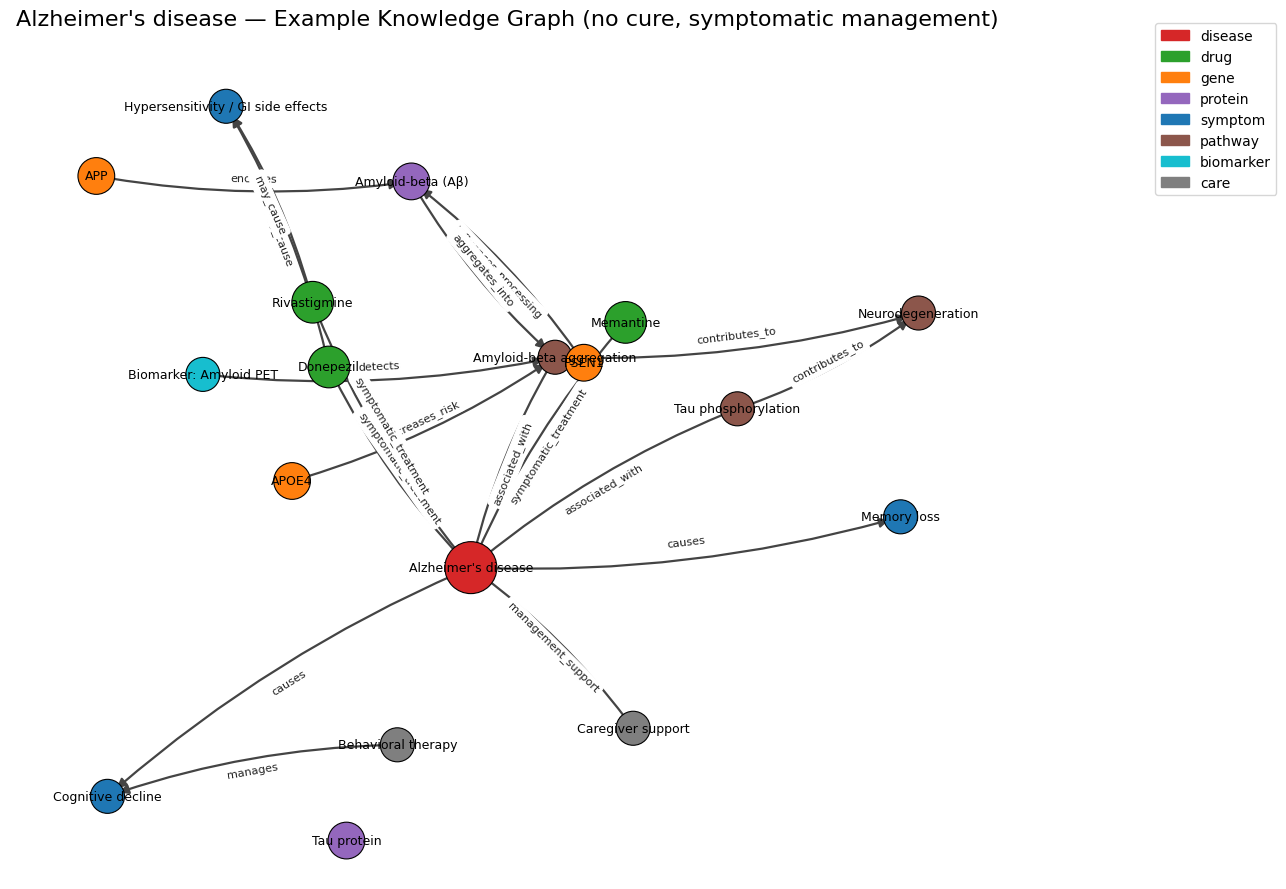

In [13]:
# alzheimers_example_graph.py
# Example: build and draw a small knowledge-graph centered on "Alzheimer's disease" (an example of a disease with no cure)
# Usage: python alzheimers_example_graph.py
# Requires: networkx, matplotlib
# The script constructs a small directed knowledge-graph, adds nodes and typed edges,
# draws a colored graph with edge labels, saves to 'alzheimers_graph.png' and displays it.

import sys
import os

try:
    import networkx as nx
    import matplotlib.pyplot as plt
except ImportError:
    # Attempt to install if missing (helpful in Colab)
    print("Installing required packages...")
    os.system(f"{sys.executable} -m pip install networkx matplotlib --quiet")
    import networkx as nx
    import matplotlib.pyplot as plt


def build_alzheimers_example_graph():
    """
    Build a small directed knowledge graph around Alzheimer's disease (no cure).
    Node attribute 'type' used for coloring:
      - disease, drug, gene, protein, symptom, pathway, biomarker, care
    Edge attribute 'relation' used for edge labels.
    """
    G = nx.DiGraph()

    # Nodes with types
    nodes = [
        ("Alzheimer's disease", {"type": "disease"}),
        ("Memory loss", {"type": "symptom"}),
        ("Cognitive decline", {"type": "symptom"}),
        ("Amyloid-beta aggregation", {"type": "pathway"}),
        ("Tau phosphorylation", {"type": "pathway"}),
        ("APP", {"type": "gene"}),
        ("PSEN1", {"type": "gene"}),
        ("APOE4", {"type": "gene"}),
        ("Amyloid-beta (Aβ)", {"type": "protein"}),
        ("Tau protein", {"type": "protein"}),
        ("Donepezil", {"type": "drug"}),
        ("Rivastigmine", {"type": "drug"}),
        ("Memantine", {"type": "drug"}),
        ("Biomarker: Amyloid PET", {"type": "biomarker"}),
        ("Caregiver support", {"type": "care"}),
        ("Behavioral therapy", {"type": "care"}),
        ("Hypersensitivity / GI side effects", {"type": "symptom"}),
    ]

    G.add_nodes_from(nodes)

    # Edges with relation labels
    edges = [
        ("APP", "Amyloid-beta (Aβ)", {"relation": "encodes"}),
        ("PSEN1", "Amyloid-beta (Aβ)", {"relation": "influences_processing"}),
        ("APOE4", "Amyloid-beta aggregation", {"relation": "increases_risk"}),
        ("Amyloid-beta (Aβ)", "Amyloid-beta aggregation", {"relation": "aggregates_into"}),
        ("Amyloid-beta aggregation", "Neurodegeneration", {"relation": "contributes_to"}),
        ("Tau phosphorylation", "Neurodegeneration", {"relation": "contributes_to"}),
        ("Amyloid-beta aggregation", "Alzheimer's disease", {"relation": "associated_with"}),
        ("Tau phosphorylation", "Alzheimer's disease", {"relation": "associated_with"}),
        ("Alzheimer's disease", "Memory loss", {"relation": "causes"}),
        ("Alzheimer's disease", "Cognitive decline", {"relation": "causes"}),
        ("Donepezil", "Alzheimer's disease", {"relation": "symptomatic_treatment"}),
        ("Rivastigmine", "Alzheimer's disease", {"relation": "symptomatic_treatment"}),
        ("Memantine", "Alzheimer's disease", {"relation": "symptomatic_treatment"}),
        ("Donepezil", "Hypersensitivity / GI side effects", {"relation": "may_cause"}),
        ("Rivastigmine", "Hypersensitivity / GI side effects", {"relation": "may_cause"}),
        ("Biomarker: Amyloid PET", "Amyloid-beta aggregation", {"relation": "detects"}),
        ("Caregiver support", "Alzheimer's disease", {"relation": "management_support"}),
        ("Behavioral therapy", "Cognitive decline", {"relation": "manages"}),
    ]

    # Add an extra node for Neurodegeneration (it wasn't in nodes list above)
    G.add_node("Neurodegeneration", type="pathway")
    # Add edges
    for u, v, attrs in edges:
        G.add_edge(u, v, **attrs)

    return G


def draw_graph(G, title="Alzheimer's disease — example knowledge graph", save_path="alzheimers_graph.png"):
    # layout: spring layout tends to distribute well for small graphs
    pos = nx.spring_layout(G, seed=42, k=0.8)

    # color mapping by node type
    type_to_color = {
        "disease": "#d62728",     # red
        "drug": "#2ca02c",        # green
        "gene": "#ff7f0e",        # orange
        "protein": "#9467bd",     # purple
        "symptom": "#1f77b4",     # blue
        "pathway": "#8c564b",     # brown
        "biomarker": "#17becf",   # cyan
        "care": "#7f7f7f",        # gray
    }
    default_color = "#bbbbbb"

    node_colors = []
    node_sizes = []
    labels = {}

    for n, d in G.nodes(data=True):
        ntype = d.get("type", None)
        node_colors.append(type_to_color.get(ntype, default_color))
        # size disease larger for emphasis
        if ntype == "disease":
            node_sizes.append(1400)
        elif ntype == "drug":
            node_sizes.append(900)
        elif ntype in ("gene", "protein"):
            node_sizes.append(700)
        else:
            node_sizes.append(600)
        # short labels: keep node text (ok for this example)
        labels[n] = n

    plt.figure(figsize=(13, 9))
    ax = plt.gca()
    ax.set_title(title, fontsize=16)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors="k", linewidths=0.8)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    # Draw directed edges
    nx.draw_networkx_edges(
        G,
        pos,
        arrowstyle='-|>',
        arrowsize=14,
        edge_color="#444444",
        connectionstyle="arc3,rad=0.08",
        width=1.6,
    )

    # Edge labels from 'relation'
    edge_labels = {(u, v): d.get("relation", "") for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="#222222", font_size=8)

    # Legend
    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=c, label=t) for t, c in type_to_color.items()]
    plt.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.28, 1.02))

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved graph to: {save_path}")
    plt.show()


if __name__ == "__main__":
    G = build_alzheimers_example_graph()
    draw_graph(G, title="Alzheimer's disease — Example Knowledge Graph (no cure, symptomatic management)", save_path="alzheimers_graph.png")